In [125]:
# first we will import all the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [126]:
# lets import our data
data=pd.read_csv('/content/lung_disease_v1.csv')

In [127]:
# lets visulazie our data
data.head()

,patient_id,age,sex,bmi,smoking_status,pack_years,pm25_exposure,occupation,family_history,cough,...,dlco_pct_pred,cxr_finding,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hypertension,diabetes,hospital_visits_last_year,disease_type,severity
0,1,49,Male,20.1,Never,21.0,20.8,Office,NaN,1,...,82.1,Normal,3.0,11.9,447,1,1,0,Asthma,Moderate
1,2,61,Female,28.4,Current,34.1,10.8,Office,NaN,0,...,81.1,Normal,5.9,2.1,394,0,0,0,Lung Cancer,Mild/None
2,3,70,Male,22.2,Current,15.7,12.0,Manufacturing,NaN,1,...,85.4,Consolidation,2.8,4.8,309,0,1,0,Pneumonia,Mild/None
3,4,47,Male,23.1,Current,49.0,20.0,Manufacturing,NaN,0,...,49.0,Normal,1.8,29.4,190,0,0,0,COPD,Moderate
4,5,70,Female,29.0,Former,6.0,6.0,Office,NaN,0,...,81.6,Normal,1.0,9.5,314,0,0,0,Healthy,Mild/None


In [128]:
# lets see more details about our data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 12000 non-null  int64  
 1   age                        12000 non-null  int64  
 2   sex                        12000 non-null  object 
 3   bmi                        12000 non-null  float64
 4   smoking_status             12000 non-null  object 
 5   pack_years                 12000 non-null  float64
 6   pm25_exposure              12000 non-null  float64
 7   occupation                 12000 non-null  object 
 8   family_history             4824 non-null   object 
 9   cough                      12000 non-null  int64  
 10  dyspnea                    12000 non-null  int64  
 11  wheeze                     12000 non-null  int64  
 12  chest_pain                 12000 non-null  int64  
 13  fever                      12000 non-null  int

In [129]:
# lets see some other mathematics terms
data.describe()

,patient_id,age,bmi,pack_years,pm25_exposure,cough,dyspnea,wheeze,chest_pain,fever,...,fev1_fvc,fev1_pct_pred,fvc_pct_pred,dlco_pct_pred,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hypertension,diabetes,hospital_visits_last_year
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,58.070833,27.008608,14.767758,15.114308,0.417333,0.397250,0.246750,0.138083,0.167000,...,0.740610,83.805633,94.915475,81.511558,4.644267,8.275508,403.809167,0.347333,0.184250,0.615833
std,3464.24595,14.741634,4.961936,14.848183,6.689190,0.493139,0.489349,0.431138,0.345002,0.372991,...,0.100471,18.773718,12.051371,17.630906,5.926454,8.290305,109.520138,0.476143,0.387704,0.738892
min,1.00000,18.000000,16.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.320000,20.000000,49.600000,20.000000,0.000000,0.000000,-29.000000,0.000000,0.000000,0.000000
25%,3000.75000,48.000000,23.500000,2.700000,10.300000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.680000,72.200000,86.800000,70.800000,1.000000,2.500000,329.000000,0.000000,0.000000,0.000000
50%,6000.50000,58.000000,27.000000,10.300000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.750000,85.100000,94.900000,82.400000,3.000000,6.300000,405.000000,0.000000,0.000000,0.000000
75%,9000.25000,68.000000,30.400000,22.800000,19.700000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.810000,96.500000,103.100000,93.500000,5.400000,10.900000,478.000000,1.000000,0.000000,1.000000
max,12000.00000,90.000000,45.600000,81.800000,41.300000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.950000,140.000000,140.000000,139.500000,47.800000,51.600000,816.000000,1.000000,1.000000,5.000000


In [130]:
# lets find missing values in our
data.isnull().sum()

,0
patient_id,0
age,0
sex,0
bmi,0
smoking_status,0
pack_years,0
pm25_exposure,0
occupation,0
family_history,7176
cough,0


In [131]:
# we will drop the column which is not important also has many missing values
data=data.drop('family_history',axis=1)

In [132]:
# will check the length our data
len(data)

12000

In [133]:
# after removing the column which has missing value lets visualize
data.head()

,patient_id,age,sex,bmi,smoking_status,pack_years,pm25_exposure,occupation,cough,dyspnea,...,dlco_pct_pred,cxr_finding,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hypertension,diabetes,hospital_visits_last_year,disease_type,severity
0,1,49,Male,20.1,Never,21.0,20.8,Office,1,0,...,82.1,Normal,3.0,11.9,447,1,1,0,Asthma,Moderate
1,2,61,Female,28.4,Current,34.1,10.8,Office,0,1,...,81.1,Normal,5.9,2.1,394,0,0,0,Lung Cancer,Mild/None
2,3,70,Male,22.2,Current,15.7,12.0,Manufacturing,1,1,...,85.4,Consolidation,2.8,4.8,309,0,1,0,Pneumonia,Mild/None
3,4,47,Male,23.1,Current,49.0,20.0,Manufacturing,0,1,...,49.0,Normal,1.8,29.4,190,0,0,0,COPD,Moderate
4,5,70,Female,29.0,Former,6.0,6.0,Office,0,0,...,81.6,Normal,1.0,9.5,314,0,0,0,Healthy,Mild/None


In [134]:
# now again for cross verification we will see any misisng values are not
data.isnull().sum()

,0
patient_id,0
age,0
sex,0
bmi,0
smoking_status,0
pack_years,0
pm25_exposure,0
occupation,0
cough,0
dyspnea,0


In [135]:
# now we will plot some graphs, and for this first we categorize the numerical_ features
num_features = [
    'age', 'bmi', 'pack_years', 'pm25_exposure',
    'weight_loss_kg', 'spo2', 'respiratory_rate',
    'crp_mg_L', 'wbc_10e9_L', 'fev1_fvc',
    'fev1_pct_pred', 'fvc_pct_pred', 'dlco_pct_pred',
    'ct_nodule_size_mm', 'ct_emphysema_pct',
    'sixmwd_m', 'hospital_visits_last_year'
]


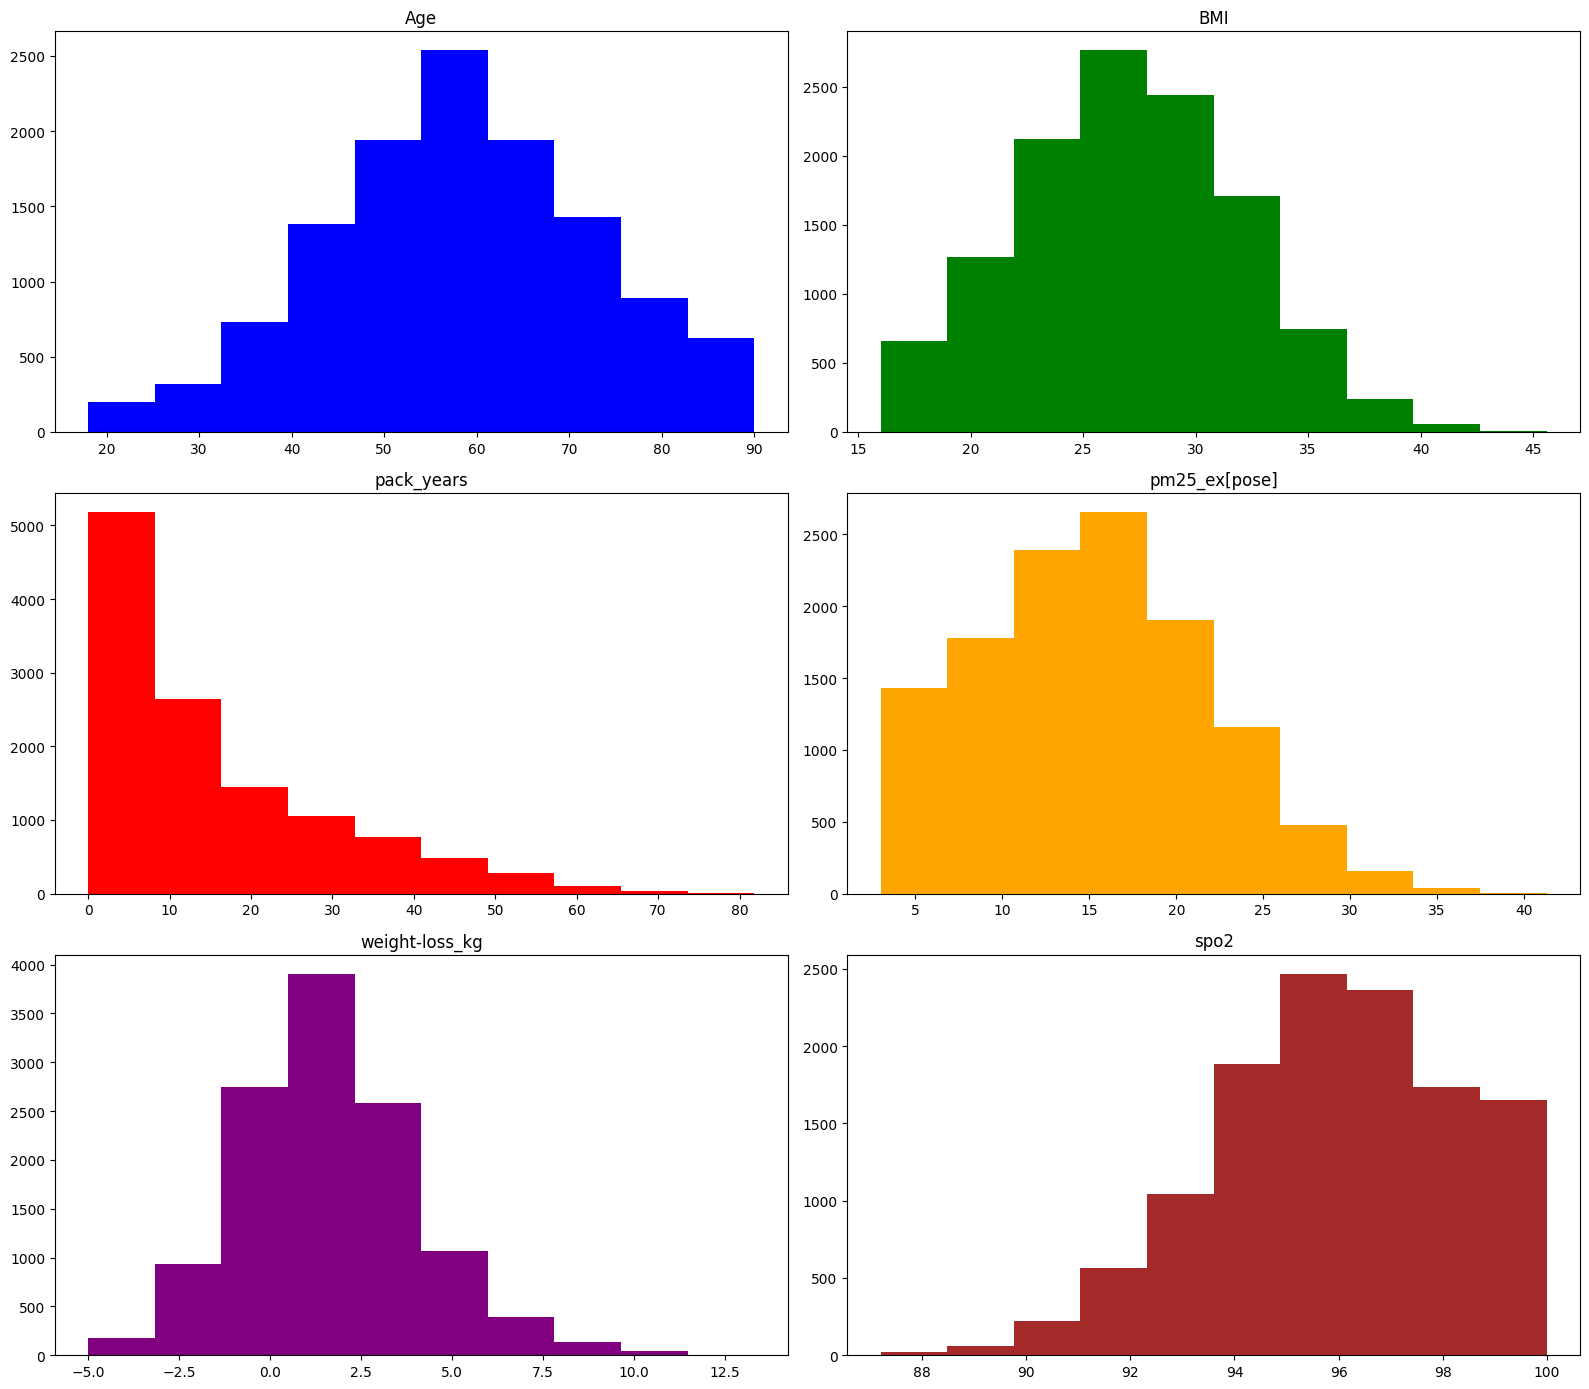

In [136]:
# here we are plotting important plots
fig, axs = plt.subplots(3, 2, figsize=(16, 14))
(ax1,ax2),(ax3,ax4),(ax5,ax6)=axs

ax1.hist(data['age'], bins=10, color='blue')
ax1.set_title('Age')

ax2.hist(data['bmi'], bins=10, color='green')
ax2.set_title('BMI')

ax3.hist(data['pack_years'], bins=10, color='red')
ax3.set_title('pack_years')

ax4.hist(data['pm25_exposure'], bins=10, color='orange')
ax4.set_title('pm25_ex[pose]')

ax5.hist(data['weight_loss_kg'], bins=10, color='purple')
ax5.set_title('weight-loss_kg')

ax6.hist(data['spo2'], bins=10, color='brown')
ax6.set_title('spo2')

plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'fvc_pct_pred')

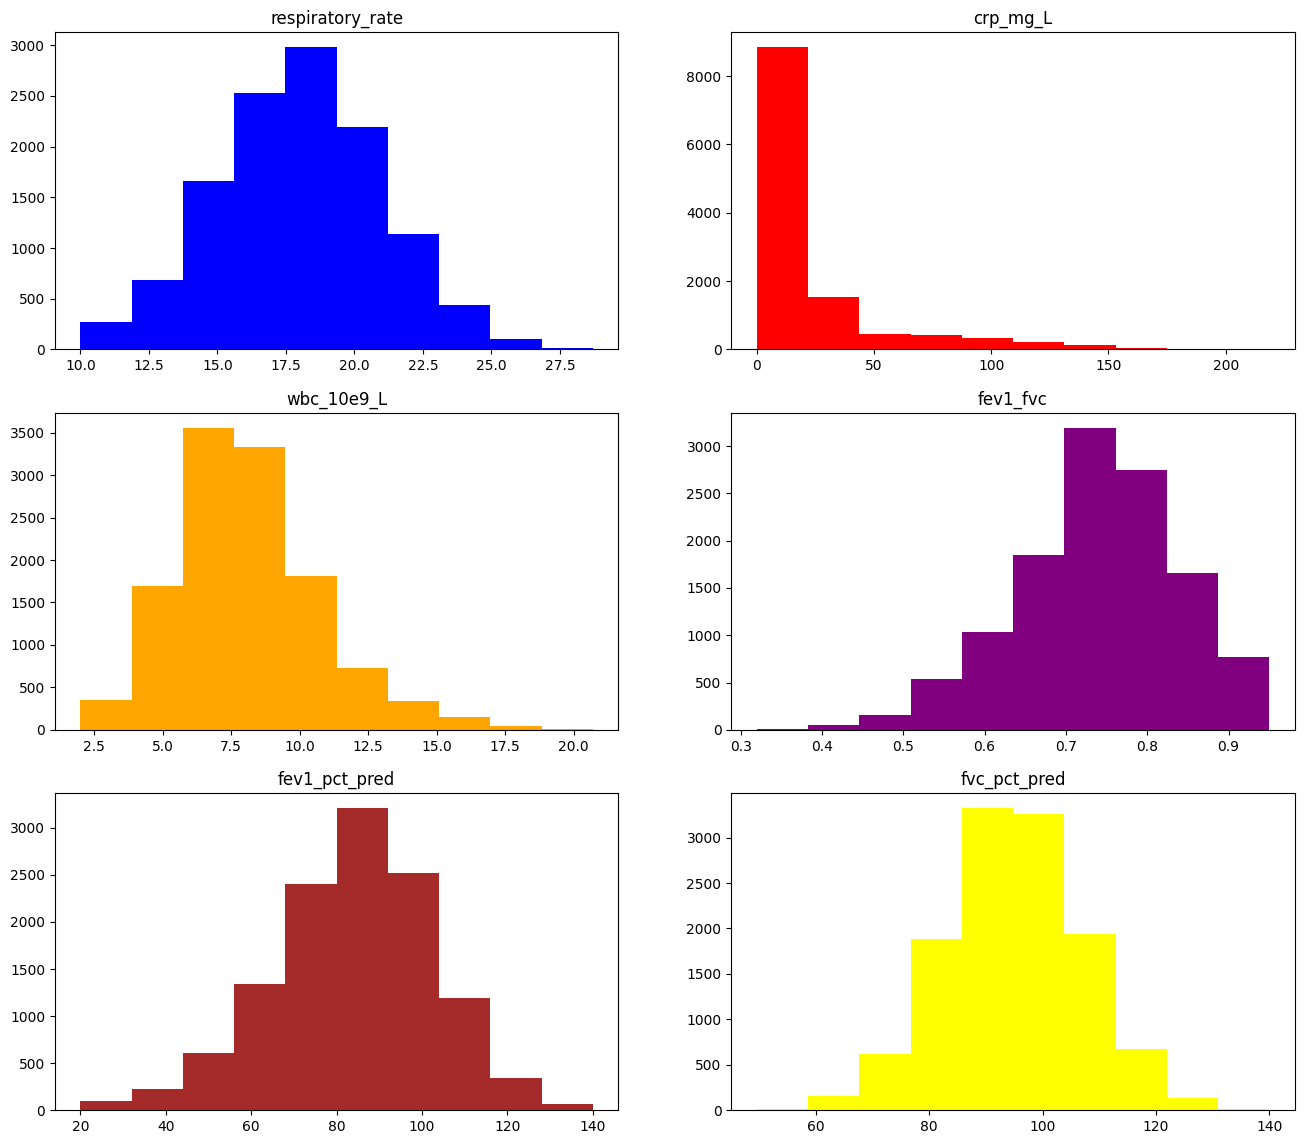

In [137]:
fig, axs = plt.subplots(3, 2, figsize=(16, 14))
(ax7,ax8),(ax9,ax10),(ax11,ax12)=axs

ax7.hist(data['respiratory_rate'], bins=10, color='blue')
ax7.set_title('respiratory_rate')

ax8.hist(data['crp_mg_L'], bins=10, color='red')
ax8.set_title('crp_mg_L')

ax9.hist(data['wbc_10e9_L'], bins=10, color='orange')
ax9.set_title('wbc_10e9_L')

ax10.hist(data['fev1_fvc'], bins=10, color='purple')
ax10.set_title('fev1_fvc')

ax11.hist(data['fev1_pct_pred'], bins=10, color='brown')
ax11.set_title('fev1_pct_pred')

ax12.hist(data['fvc_pct_pred'], bins=10, color='yellow')
ax12.set_title('fvc_pct_pred')

In [138]:
#let use labelencoder to encode our tARGET
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['disease_encoded'] = le.fit_transform(data['disease_type'])

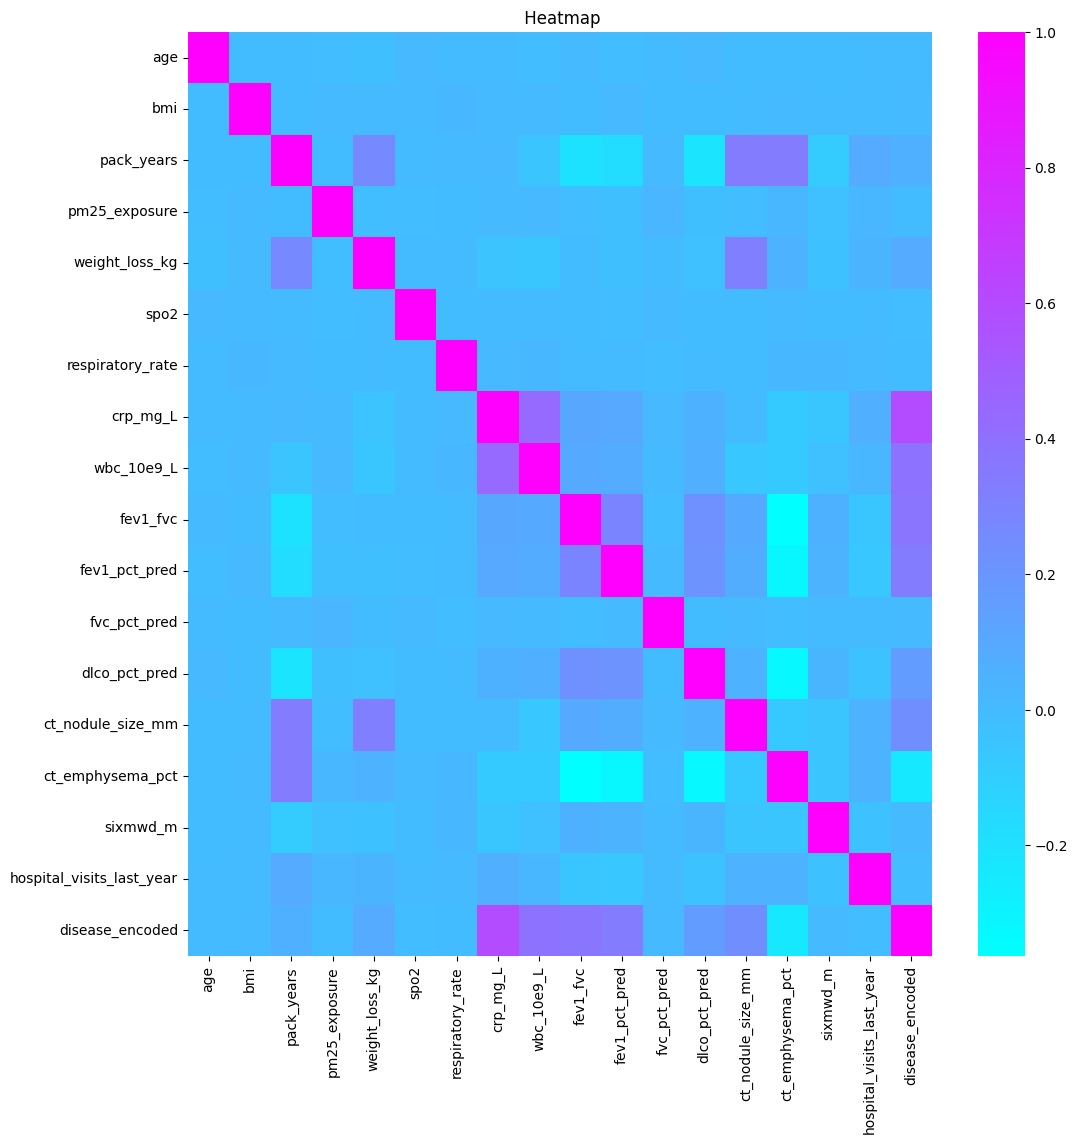

In [139]:
#for further visualization we will print the heat map
corr_matrix = data[num_features + ['disease_encoded']].corr()

plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix,cmap="cool",annot=False)
plt.title(" Heatmap")
plt.show()

Identify Features Strongly Linked to Lung Disease Categories


In [140]:
# overALL mean comparsion
overall_means = data.groupby('disease_type')[num_features].mean()
overall_means

,age,bmi,pack_years,pm25_exposure,weight_loss_kg,spo2,respiratory_rate,crp_mg_L,wbc_10e9_L,fev1_fvc,fev1_pct_pred,fvc_pct_pred,dlco_pct_pred,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hospital_visits_last_year
disease_type,,,,,,,,,,,,,,,,,
Asthma,58.216463,26.953506,6.231555,15.084654,1.052541,96.026372,18.037957,7.232724,7.495071,0.709477,78.279014,94.803557,84.826931,3.226931,5.385671,389.814533,0.714939
COPD,57.821146,27.051653,30.008989,15.424406,1.982394,96.005263,17.964928,13.500512,7.429110,0.628924,65.467443,94.975827,64.474429,3.304192,20.964788,389.088030,0.744294
Healthy,58.128683,26.964436,6.341386,15.022413,0.999835,95.908932,17.934127,6.990573,7.464601,0.779128,90.132689,94.802734,85.297737,2.195663,5.495805,429.300731,0.422578
Lung Cancer,57.883212,26.985345,29.771982,14.867827,4.023021,95.948905,17.946996,18.343178,7.540988,0.779893,90.199495,94.983099,85.255587,15.163054,5.514374,390.158899,0.702414
Pneumonia,58.252552,27.140193,11.063783,15.233315,0.943364,95.982697,18.033799,77.360559,11.477378,0.776969,90.262010,95.156529,85.445567,3.205212,5.672166,390.535733,0.720580


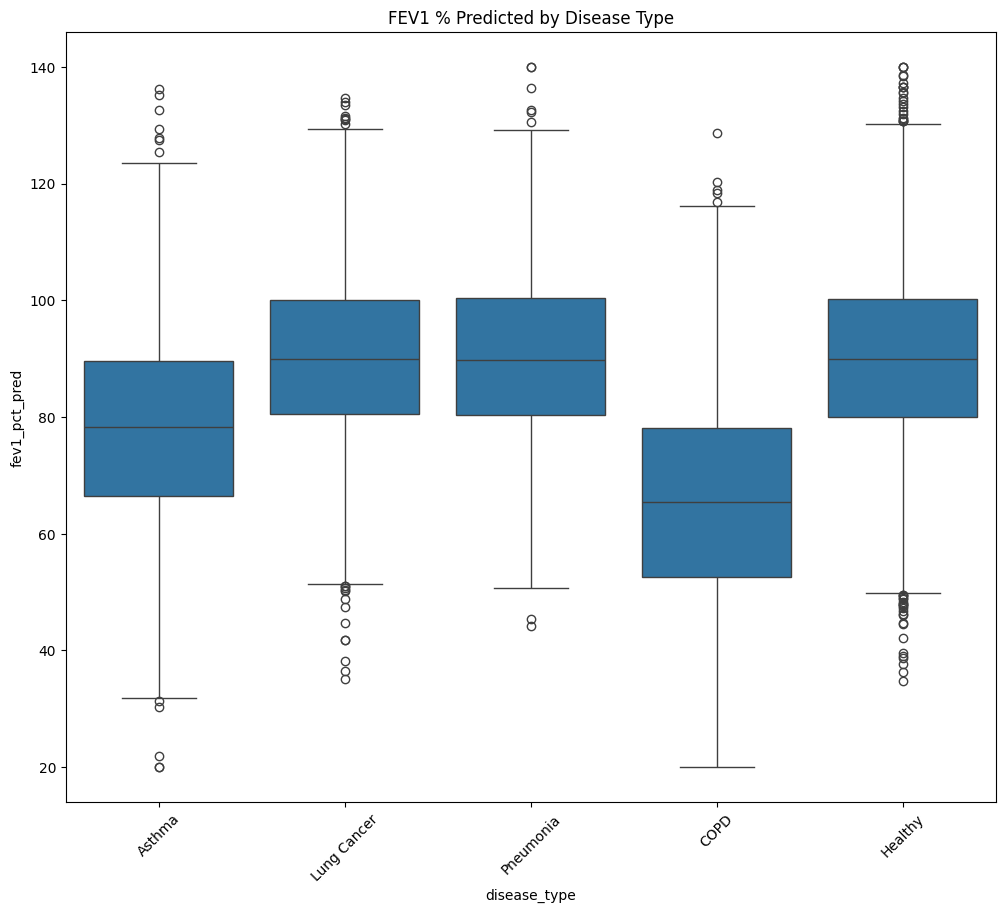

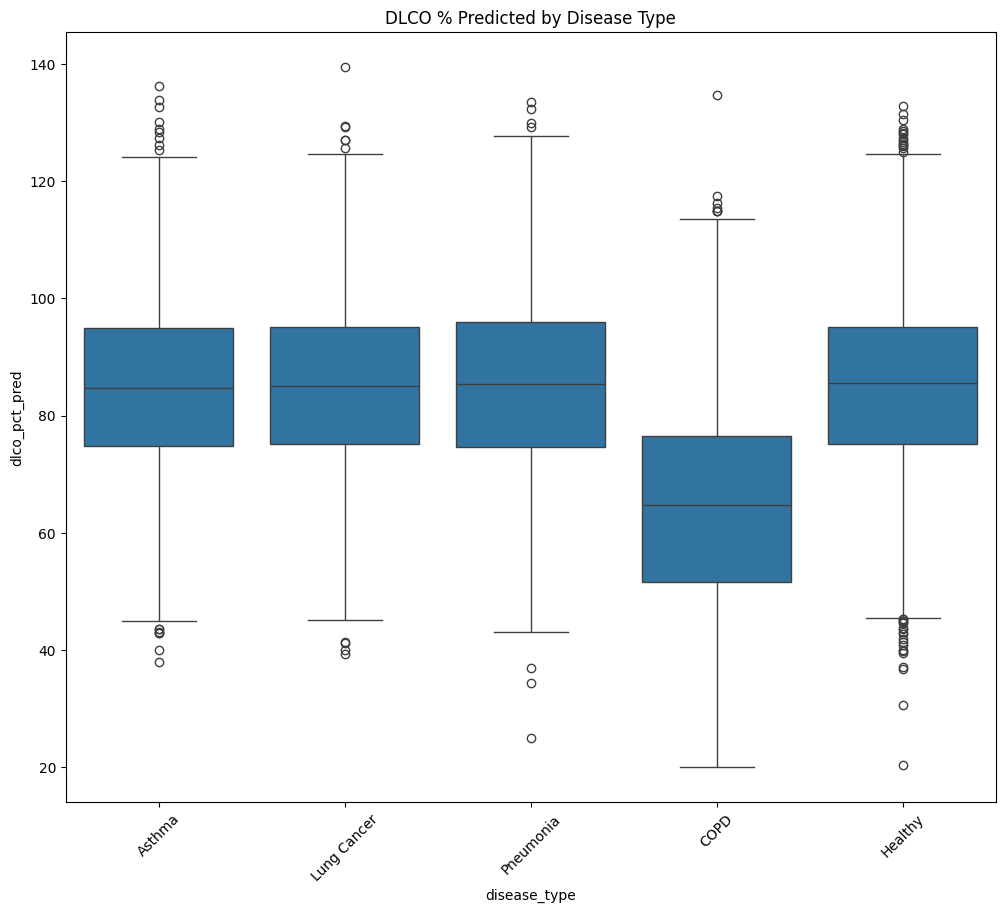

In [141]:
# lung functions measures vary significantly across disease categotion

plt.figure(figsize=(12,10))
sns.boxplot(x='disease_type', y='fev1_pct_pred', data=data)
plt.title("FEV1 % Predicted by Disease Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,10))
sns.boxplot(x='disease_type', y='dlco_pct_pred', data=data)
plt.title("DLCO % Predicted by Disease Type")
plt.xticks(rotation=45)
plt.show()

In [142]:
# seprate futures and target variables
X = data.drop(columns=['disease_type'])
y = data['disease_type']

In [143]:
# encoding categration variables
categorical_columns = [
    'sex', 'smoking_status', 'occupation',
    'cxr_finding', 'severity'
]

In [144]:
# apply one hot encoding
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

In [145]:
# scaler numerical features
num_cols = [
    'age', 'bmi', 'pack_years', 'pm25_exposure',
    'weight_loss_kg', 'spo2', 'respiratory_rate',
    'crp_mg_L', 'wbc_10e9_L', 'fev1_fvc',
    'fev1_pct_pred', 'fvc_pct_pred', 'dlco_pct_pred',
    'ct_nodule_size_mm', 'ct_emphysema_pct',
    'sixmwd_m', 'hospital_visits_last_year'
]

In [146]:
# apply standard scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [147]:
# before scaling
data[num_cols].head()

,age,bmi,pack_years,pm25_exposure,weight_loss_kg,spo2,respiratory_rate,crp_mg_L,wbc_10e9_L,fev1_fvc,fev1_pct_pred,fvc_pct_pred,dlco_pct_pred,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hospital_visits_last_year
0,49,20.1,21.0,20.8,-3.3,96.7,15.3,18.6,8.5,0.51,54.7,85.9,82.1,3.0,11.9,447,0
1,61,28.4,34.1,10.8,2.5,90.4,15.6,13.4,6.0,0.80,96.7,103.3,81.1,5.9,2.1,394,0
2,70,22.2,15.7,12.0,1.7,96.2,14.7,54.5,14.8,0.72,82.4,87.4,85.4,2.8,4.8,309,0
3,47,23.1,49.0,20.0,4.9,97.3,18.5,16.1,10.5,0.61,62.9,100.5,49.0,1.8,29.4,190,0
4,70,29.0,6.0,6.0,1.3,97.0,14.1,4.3,6.3,0.87,59.1,114.1,81.6,1.0,9.5,314,0


In [148]:
# After scaling
X[num_cols].head()

,age,bmi,pack_years,pm25_exposure,weight_loss_kg,spo2,respiratory_rate,crp_mg_L,wbc_10e9_L,fev1_fvc,fev1_pct_pred,fvc_pct_pred,dlco_pct_pred,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hospital_visits_last_year
0,-0.615346,-1.392379,0.419748,0.850018,-2.032802,0.310280,-0.893363,-0.071660,0.154640,-2.295393,-1.550404,-0.748118,0.033377,-0.277457,0.437215,0.394381,-0.83349
1,0.198709,0.280425,1.302048,-0.644994,0.361543,-2.341330,-0.793136,-0.241566,-0.804427,0.591143,0.686859,0.695761,-0.023344,0.211895,-0.744938,-0.089569,-0.83349
2,0.809250,-0.969140,0.062788,-0.465593,0.031288,0.099835,-1.093816,1.101350,2.571490,-0.205143,-0.074876,-0.623646,0.220556,-0.311205,-0.419243,-0.865714,-0.83349
3,-0.751022,-0.787751,2.305580,0.730417,1.352306,0.562815,0.175719,-0.153346,0.921894,-1.300036,-1.113605,0.463413,-1.844086,-0.479947,2.548202,-1.952317,-0.83349
4,0.809250,0.401350,-0.590518,-1.362600,-0.133839,0.436548,-1.294268,-0.538903,-0.689339,1.287892,-1.316024,1.591962,0.005016,-0.614941,0.147708,-0.820058,-0.83349


In [149]:
# final prepare data set
X.shape, y.shape

((12000, 45), (12000,))

In [150]:
# Train_test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((9600, 45), (2400, 45))

In [151]:
# assing model
model_1=LogisticRegression(max_iter=1000)

# now will fit the model
model_1.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [30]:
# assing model_2
model_2=SVC(probability=True)

# now will fit the model
model_2.fit(X_train,y_train)


SVC(probability=True)

In [31]:
# assign model_3
model_3=DecisionTreeClassifier(random_state=42)

# now will fit the
model_3.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [32]:
# assign model_4
model_4=RandomForestClassifier(random_state=42)

# now will fit the
model_4.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [33]:
# now will assign model_5
model_5=KNeighborsClassifier()

# now will fit the
model_5.fit(X_train,y_train)

KNeighborsClassifier()

In [34]:
# Important evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import  confusion_matrix,classification_report,roc_curve,auc



In [35]:
trained_models = {
    'Logistic Regression': model_1,
    'Support Vector Machine': model_2,
    'Decision Tree': model_3,
    'Random Forest': model_4,
    'K-Nearest Neighbors': model_5
}

In [36]:
# Evalute all models using multiple metrices
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, accuracy, precision, recall, f1])

results_overall = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
)

results_overall

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.995000,0.995015,0.995000,0.994991
1,Support Vector Machine,0.353750,0.125139,0.353750,0.184878
2,Decision Tree,1.000000,1.000000,1.000000,1.000000
3,Random Forest,0.999583,0.999584,0.999583,0.999583
4,K-Nearest Neighbors,0.368333,0.394307,0.368333,0.347858


In [37]:
# comparative result table
results_overall.sort_values(by='F1-score', ascending=True)

,Model,Accuracy,Precision,Recall,F1-score
1,Support Vector Machine,0.353750,0.125139,0.353750,0.184878
4,K-Nearest Neighbors,0.368333,0.394307,0.368333,0.347858
0,Logistic Regression,0.995000,0.995015,0.995000,0.994991
3,Random Forest,0.999583,0.999584,0.999583,0.999583
2,Decision Tree,1.000000,1.000000,1.000000,1.000000


In [38]:
# select best model
best_model_name = results_overall.sort_values(
    by='F1-score', ascending=False
).iloc[0]['Model']

best_model = trained_models[best_model_name]
best_model_name

'Decision Tree'

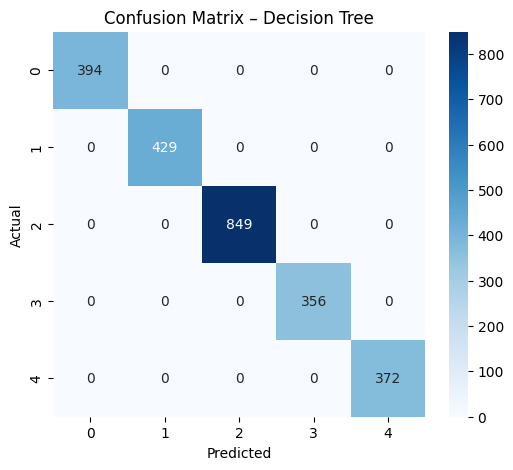

In [39]:
# plot confusion matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix – {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [40]:
# encoding target for roc
from sklearn.preprocessing import label_binarize

classes = y.unique()
y_test_bin = label_binarize(y_test, classes=classes)

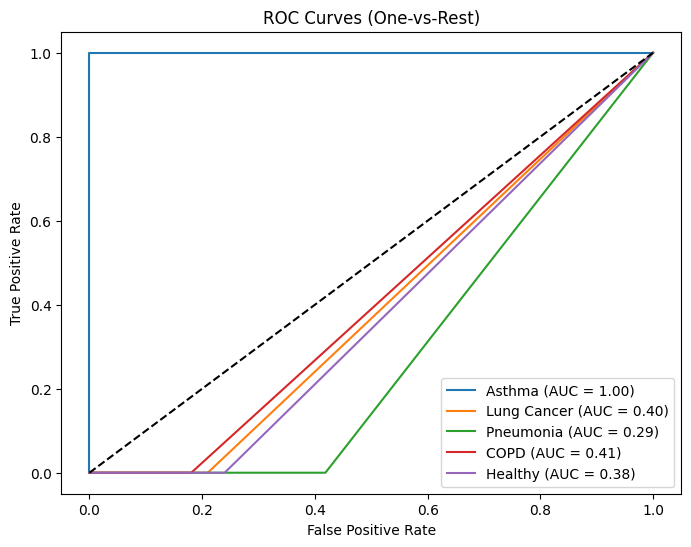

In [41]:
#plot roc curve for the coding
plt.figure(figsize=(8,6))

for i, class_label in enumerate(classes):
    y_score = best_model.predict_proba(X_test)[:, i]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_label} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend()
plt.show()


HYPERPARAMETER TUNING

In [42]:
# random forest tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted')

In [43]:
# besyt parametres and performance
grid.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

In [44]:
tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

      Asthma       1.00      1.00      1.00       394
        COPD       1.00      1.00      1.00       429
     Healthy       1.00      1.00      1.00       849
 Lung Cancer       1.00      1.00      1.00       356
   Pneumonia       1.00      1.00      1.00       372

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



MODEL INTERPRETATION

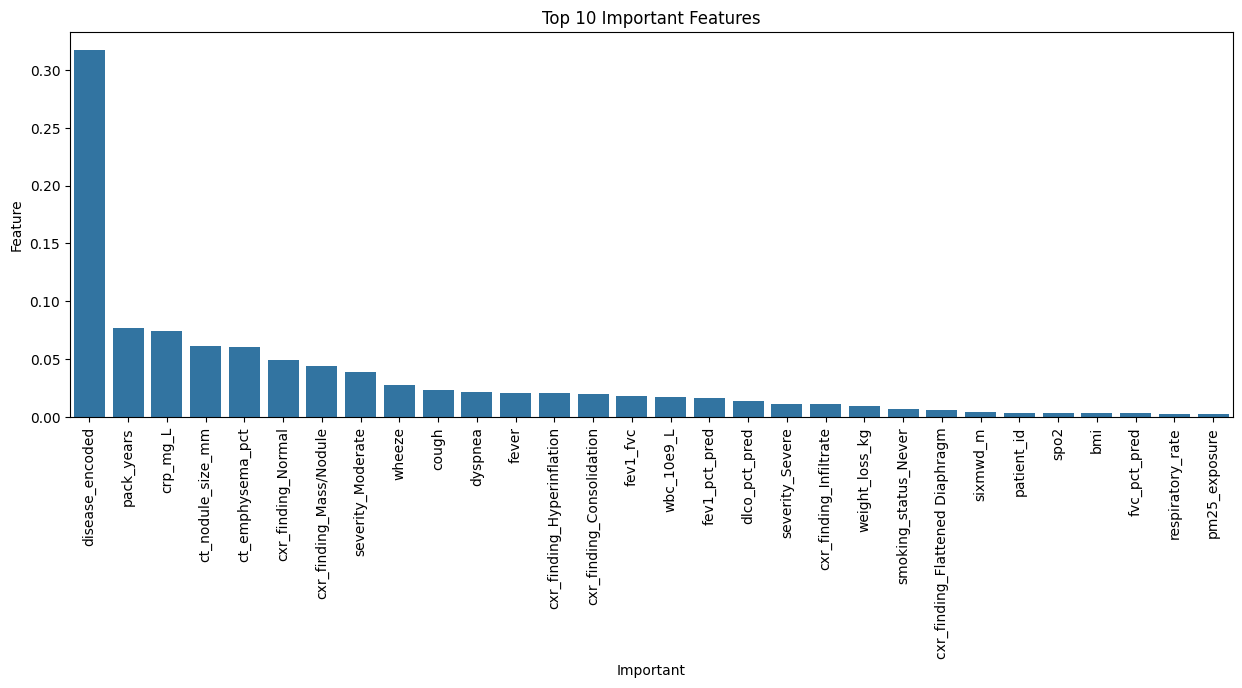

In [163]:
# FEATURE IMPORTANCE
importances = tuned_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Important': X.columns,
    'Feature': importances
}).sort_values(by='Feature', ascending=False)

feature_importance_df.head(30)

plt.figure(figsize=(15,5))
sns.barplot(
    x='Important',
    y='Feature',
    data=feature_importance_df.head(30)
)
plt.xticks(rotation=90)
plt.title('Top 10 Important Features')
plt.show()